## Travel Planner Agent | Orchestrator-Worker Workflow | LangGraph

### Problem Statement

An intelligent system that coordinates multiple specialized
agents to search flights, hotels, plan itineraries, and provide
personalized travel recommendations.


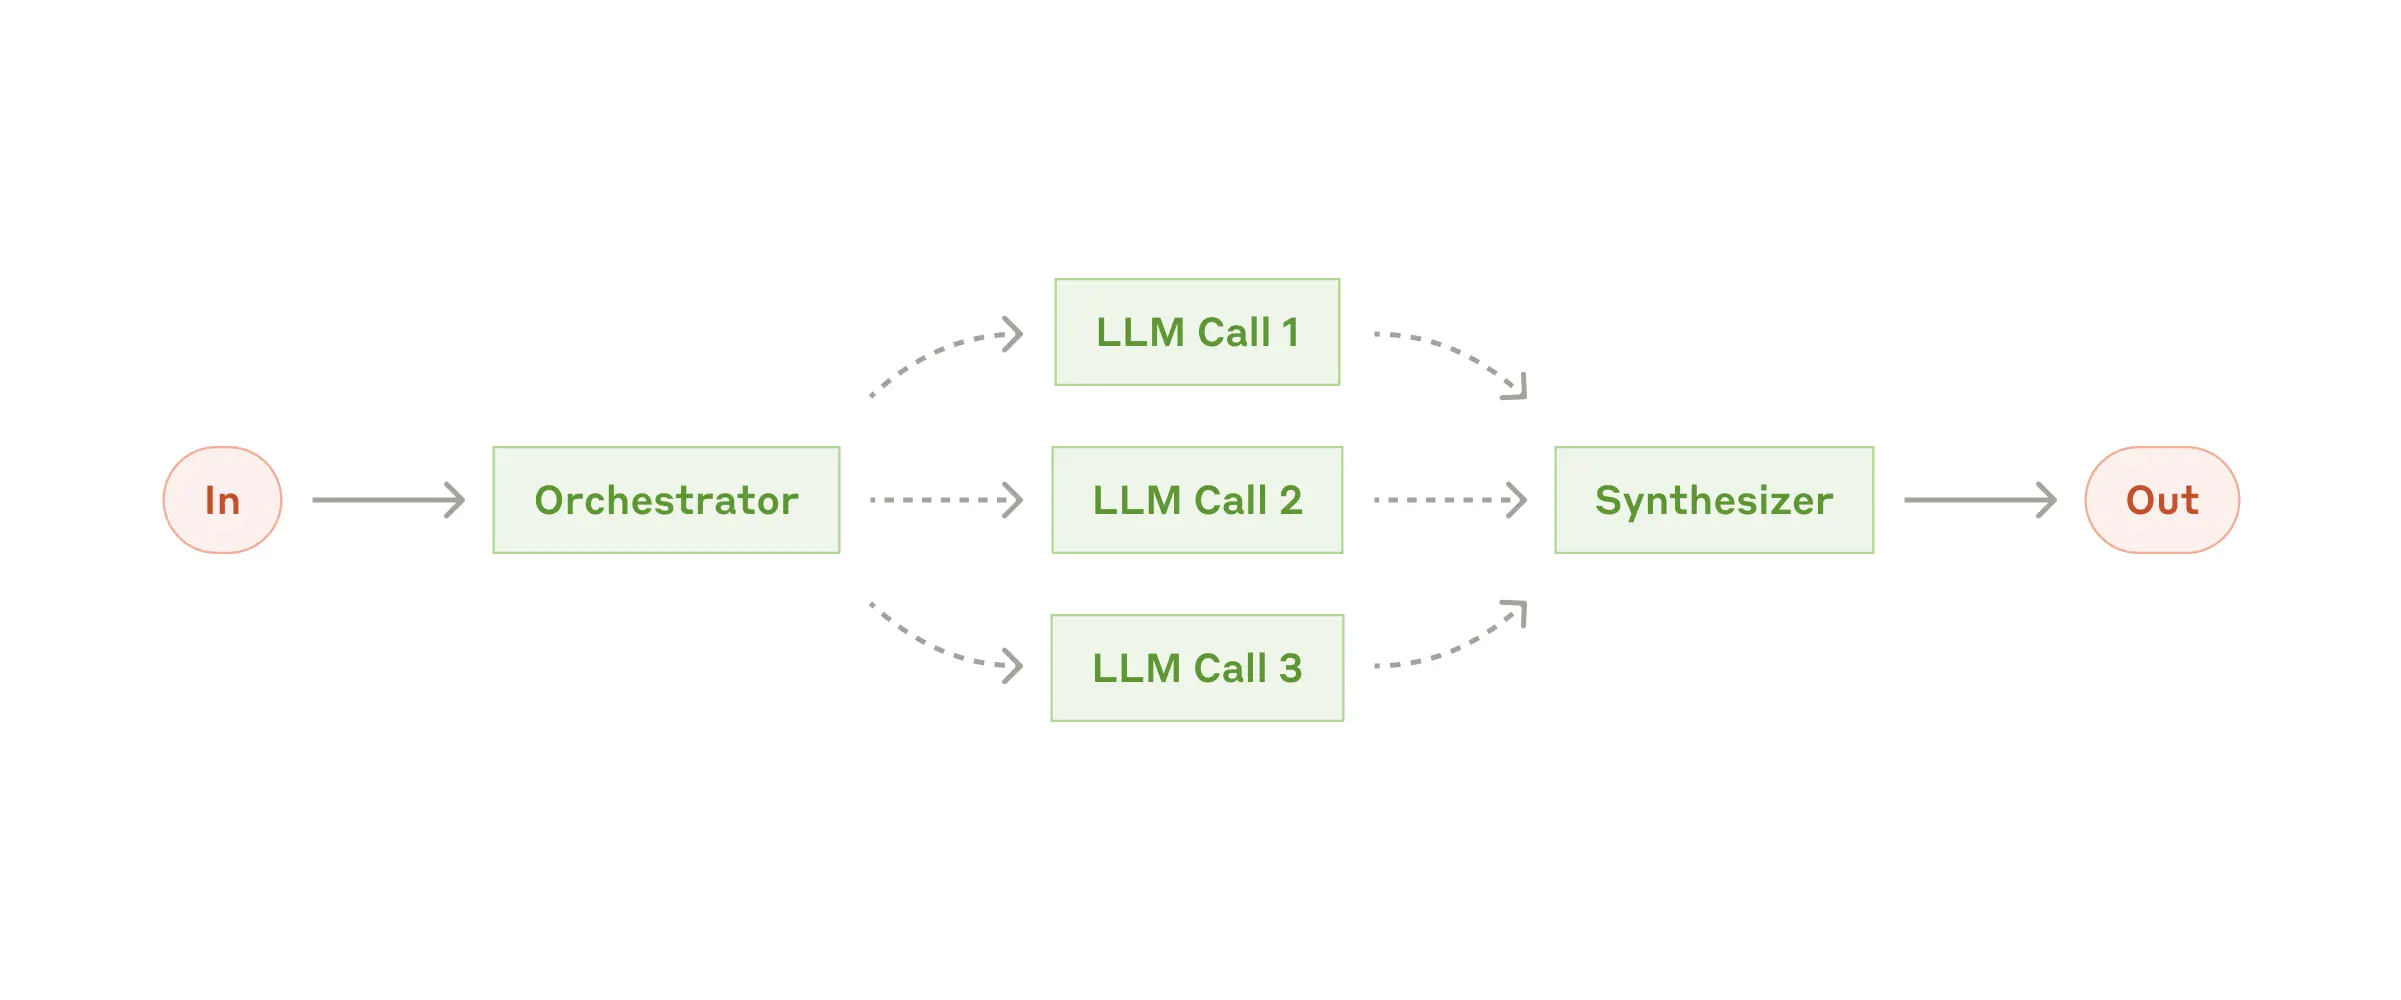


### Step 1: Setup

In [ ]:
import os
import json
from dotenv import load_dotenv
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from uuid import uuid4 as uuid
from datetime import date

In [ ]:
load_dotenv()

openAI_key = os.getenv("openAI_key")
tavily_key = os.getenv("tavily_key")
serpapi_key = os.getenv("serpapi_key")

In [ ]:
from typing import Annotated, List
import operator
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.constants import Send

C:\Users\iamni\AppData\Local\Temp\ipykernel_9328\2907212395.py:11: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4, openai_api_key=openAI_key)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=openAI_key)

In [ ]:
# test model


response = llm.invoke("Hello, how are you?")
print(response.content)

del response

embeddings_response = embeddings.embed_documents(["Hello", "Bye"])
print(embeddings_response[0][:5])

del embeddings_response

Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
[0.0192108154296875, -0.06451416015625, -0.0017137527465820312, 0.07806396484375, 0.0215911865234375]


### Step 2: Define State

In [ ]:
class WorkerResult(TypedDict):
    worker_name: str
    output: str

class State(TypedDict):
    user_input: str
    selected_workers: List[str]
    worker_outputs: Annotated[List[WorkerResult], operator.add]
    messages: Annotated[List[AnyMessage], add_messages]
    final_output: str

state = State()

In [ ]:
def dispatch_workers(state: State):
    "It is just deciding the next node, not executing as a node. So it is not a node, but a function that decides the next node to execute."
    selected_workers = state.get("selected_workers", [])

    if not selected_workers:
        return "end"

    return [
        Send(worker, state)
        for worker in selected_workers
    ]

### Step 3: Orchestrator-Worker Node

In [ ]:
agent_description = {
    "travel_planning_agent": """
        Helps in Travel Planning, Flight and Hotel Booking, Flight Recommendations, Hotel Recommendations.
    """,
    "itinerary_agent": """
        Itinerary Planning, Site-seeing Recommendations, Local Experience Recommendations, Food Recommendations.
    """
}

agent_embeddings = {}

for agent_name, description in agent_description.items():
    agent_embeddings[agent_name] = embeddings.embed_query(description)

with open("agent_embeddings.json", "w") as f:
    json.dump(agent_embeddings, f)

del agent_embeddings, agent_description

In [ ]:
@tool
def route_selection(query: str) -> List[str]:
    """Selects the appropriate route (agent) based on the user query."""
    input_embedding = np.array(embeddings.embed_query(query)).reshape(1, -1)

    with open("agent_embeddings.json", "r") as f:
        AGENT_EMBEDDINGS = json.load(f)

    travel_planner_embedding = np.array(AGENT_EMBEDDINGS["travel_planning_agent"]).reshape(1, -1)
    itinerary_embedding = np.array(AGENT_EMBEDDINGS["itinerary_agent"]).reshape(1, -1)

    travel_score = cosine_similarity(input_embedding, travel_planner_embedding)[0][0]
    itinerary_score = cosine_similarity(input_embedding, itinerary_embedding)[0][0]

    if abs(travel_score - itinerary_score) < 0.05:
        return ["travel_planning_agent", "itinerary_agent"]
    if travel_score > itinerary_score:
        return ["travel_planning_agent"]
    else:
        return ["itinerary_agent"]

In [ ]:
def orchestrator(state: State) -> str:
    """Orchestrates the workflow based on the current state and user input."""

    user_input = state["user_input"]
    history = state.get("messages", []) or []

    orchestrator_llm = llm.bind_tools([route_selection])

    prompt_template = """
        You are an orchestrator-worker manager.

        You have access to the tool:
        - route_selection

        Call route_selection ONLY when the latest user query asks for a NEW:
        - trip planning
        - travel planning
        - hotel booking
        - flight booking
        - itinerary generation

        Do NOT call route_selection for follow-up questions like:
        - summarize the plan
        - make it shorter
        - explain the previous plan
        - what was the hotel?
        - what was the flight?

        For follow-up questions, use conversation history and answer directly.

    """
    messages = [
        SystemMessage(content=prompt_template),
        *history,
        HumanMessage(content=user_input)
    ]

    response = orchestrator_llm.invoke(messages)

    print("Tool calls:", response.tool_calls)

    if response.tool_calls:
        tool_call = response.tool_calls[0]
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        print(f"Decision Trace: {response.content or ""}")

        if tool_name == "route_selection":
            selected_route = route_selection.invoke(tool_args)
            print(f"Selected Route: {selected_route}")

            return {
                "selected_workers": selected_route,
                "messages": [
                    HumanMessage(content=user_input)
                ]
            }

    return {
        "selected_workers": [],
        "final_output": response.content,
        "messages": [
            HumanMessage(content=user_input),
            AIMessage(content=response.content)
        ]
    }

### Step 4: Worker Tools

In [ ]:
from langchain_tavily import TavilySearch

tavilyClient = TavilySearch(
    max_results=5,
    tavily_api_key=tavily_key
)

from serpapi import Client

serpClient = Client(api_key=serpapi_key)

In [ ]:
# test apis

results = tavilyClient.invoke({"query": "what is langchain", "search_depth": "advanced"})
print(json.dumps(results["results"], indent=2))

del results



[
  {
    "url": "https://www.techtarget.com/searchenterpriseai/definition/LangChain",
    "title": "What Is LangChain and How to Use It: A Guide | Definition from TechTarget",
    "content": "# What is LangChain and how to use it: A guide\n\nBy\n\n Kinza Yasar, Technical Writer\n Cameron Hashemi-Pour, Former Site Editor\n\nPublished: Jan 02, 2025\n\nLangChain is an open source framework that enables software developers working with artificial intelligence (AI) and its machine learning subset to combine large language models with other external components to develop LLM-powered applications.\n\nLangChain aims to link powerful LLMs, such as OpenAI's GPT-3.5 and GPT-4, to an array of external data sources to create and reap the benefits of natural language processing (NLP) applications. It's also used for creating interfaces that produce humanlike responses and answer questions. [...] Retrieval modules. LangChain supports the development of RAG systems with tools for transforming, storin

In [ ]:
# params = {
#   "engine": "google_flights",
#   "departure_id": "DEL",   # Delhi
#   "arrival_id": "BOM",     # Mumbai
#   "outbound_date": "2026-06-17",
#   "return_date": "2026-06-23",
#   "currency": "INR",
#   "adults": 1
# }

params = {
  "engine": "google",
  "q": "Delhi airpot code"
}

results = serpClient.search(params).as_dict()

print(results['answer_box'].get('answer'))

del results, params

DEL


In [ ]:
@tool
def get_iata_codes(query: str) -> List[str]:
    """Using the SerpAPI to get IATA codes for airports."""


    prompt_template = """
    You are an assistant that helps in extracting location information from user queries for flight booking.

    Example:
    1. If the user query is "Plan a trip from Delhi to Mumbai",
    then you should extract the departure and arrival locations as "Delhi" and "Mumbai", respectively.

    response:
    {{
        "departure_location": "Delhi",
        "arrival_location": "Mumbai"
    }}

    2. If the user query is "Plan a trip to Los Angeles",
    response:
    {{
        "departure_location": "N/A",
        "arrival_location": "Los Angeles"
    }}

    3. If the user query is "Plan a trip from delhi to mumbai for 23rd June to 1st of July."

    response:
    {{
        "departure_location": "Delhi",
        "arrival_location": "Mumbai"
    }}


    User Query:
    {query}

    Reminder:
    - Extract the departure and arrival locations from the user query.
    - Do not extract any other information.
    - Always return the response in the specified JSON format and with the same keys.
    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | JsonOutputParser()).invoke({"query": query})

    iata_list = []

    print(response)

    for _, value in response.items():
        city = value.strip()

        if city == "N/A":
            iata_list.append("N/A")
            continue

        iata_list.append(city)

    prompt_template = """
        You are expert in finding the IATA code for the provided cities.

        User Query:
        {iata_list}

        Response Format:
        {{
            "Depature_id": "IATA Code",
            "Arrival_id": "IATA Code"
        }}

        Remember:
        - Only provide the IATA code for that particular city which is mentioned in the user query.
        - If not found, then provide value as N/A, don't hallucinate and create random IATA code.

        Example:
        1. If the user query list is:
        {{
            "departure_location": "Delhi",
            "arrival_location": "Mumbai"
        }}

        Then the response is:
        {{
            "Depature_id": "DEL",
            "Arrival_id": "BOM"
        }}

        2. If the user query list is:
        {{
            "departure_location": "Delhi",
            "arrival_location": "Shimla"
        }}

        Then the response is:
        {{
            "Depature_id": "DEL",
            "Arrival_id": "N/A"
        }}
    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)
    response = (PROMPT | llm | JsonOutputParser()).invoke(
        {"iata_list": iata_list}
    )

    final_list = []

    final_list.append(response.get('Depature_id', 'N/A'))
    final_list.append(response.get('Arrival_id', 'N/A'))

    print(final_list)

    return final_list



@tool
def flight_booking_tool(query: str, iata_codes: List[str]) -> str:
    """Using the SerpAPI for flight booking related queries."""
    prompt_template = """
        You are a flight booking agent.
        You have access to the SerpAPI for flight booking related queries.
        Use the SerpAPI to answer the user query related to flight booking using google flights engine.

        SerpAPI takes google flights engine takes parameters like departure_id, arrival_id, outbound_date, return_date, currency, and adults.

        Important Information:
        - Today's date is {today_date}.
        - Departure and Arrival IDs are the IATA codes for airports are {depature_codes} and {arrival_codes}, respectively.

        Response Format:
        {{
            "outbound_date": "YYYY-MM-DD",
            "return_date": "YYYY-MM-DD",
            "adults": number
        }}

        User Query:
        {query}


        For example,
        1. if the user query is:
        "Book a flight from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult",
        you should extract the parameters and call the SerpAPI with those parameters.

        response = {{
            "outbound_date": "2026-06-17",
            "return_date": "2026-06-23",
            "adults": 1
        }}

        2. if the user query is:
        "Find me a flight from New York to Los Angeles",
        you should extract the parameters and call the SerpAPI with those parameters, and if no dates are provided, then it will be 5 days round trip from next week monday.
        And if no adults are provided, then it will be 1 adult.

        response = {{
            "outbound_date": "2026-07-22",
            "return_date": "2026-07-26",
            "adults": 1
        }}

        3. if the user query is:
        "Find me a flight from New York to Los Angeles on 22nd July 2026 and return on 26th July 2026 for 2 adults",
        you should extract the parameters and call the SerpAPI with those parameters.

        response = {{
            "outbound_date": "2026-07-22",
            "return_date": "2026-07-26",
            "adults": 2
        }}

        Reminder:
        - If the user query is not related to flight booking, then do not call the SerpAPI and answer directly.
        - If the user query is related to flight booking, then call the SerpAPI with the extracted parameters and return the results.
        - If the user query is related to flight booking, then do not answer directly and only call the SerpAPI with the extracted parameters and return the results.
        - Results should be returned in the specified JSON format and with the same keys.

    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | JsonOutputParser()).invoke({
        "today_date": date.today().strftime("%Y-%m-%d"),
        "depature_codes": iata_codes[0],
        "arrival_codes": iata_codes[1],
        "query": query
    })

    params = {
        "engine": "google_flights",
        "departure_id": iata_codes[0],
        "arrival_id": iata_codes[1],
        "outbound_date": response["outbound_date"],
        "return_date": response["return_date"],
        "currency": "INR",
        "adults": response["adults"]
    }

    results = serpClient.search(params)

    return json.dumps(results.as_dict(), indent=2)


@tool
def hotel_booking_tool(query: str) -> str:
    """Using the SerpAPI for hotel booking related queries."""
    prompt_template = """
        You are a hotel booking agent.
        You have to build a parameter dictionary for the SerpAPI for hotel booking related queries.

        SerpAPI takes google hotels engine takes parameters like location, checkin_date, checkout_date, currency, and adults.

        Important Information:
        - Today's date is {today_date}.

        Response Format:
        {{
            "location": <str>,
            "checkin_date": <YYYY-MM-DD>,
            "checkout_date": <YYYY-MM-DD>,
            "adults": number
        }}

        User Query:
        {query}

        Example:
        1. 1. if the user query is:
        "Book a flight from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult",
        then exract the destination locaiton as Mumbai, number of adults as 1 and checkin_date as 2026-06-17 and checkout_date is 2026-06-23,
        and format it according to response format.

        Reminder:
        - If the user query is related to hotel booking, then do not answer directly and only create a parameter dictionary for using response format for the SerpAPI   and return the results.
        - Results should be returned in the specified JSON format and with the same keys.

    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | JsonOutputParser()).invoke({
        "today_date": date.today().strftime("%Y-%m-%d"),
        "query": query
    })

    params = {
        "engine": "google_hotels",
        "location": response["location"],
        "checkin_date": response["checkin_date"],
        "checkout_date": response["checkout_date"],
        "currency": "INR",
        "adults": response["adults"]
    }

    results = serpClient.search(params)

    return json.dumps(results.as_dict(), indent=2)

@tool
def itinerary_planning_tool(query: str) -> str:
    """Using the Tavily API for itinerary planning related queries."""
    prompt_template = """
        You are an itinerary planning agent.
        Re-write the query to be more specific and clear for the Tavily API for itinerary planning related queries.



        User Query:
        {query}

        Example:
        1. If the user query is "Plan a 3-day trip to Paris for 2 adults",
        then you should re-write the query to be more specific and clear for the Tavily API.
        response = "Plan a 3-day trip to Paris for 2 adults, including sightseeing, local experiences, and food recommendations."


        Reminder:
        - If the user query is related to itinerary planning, then do not answer directly and only re-write the query to be more specific and clear for the Tavily API to consume.
        - Return only the rewritten query.
        - Do not return JSON, only return string.

    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | StrOutputParser()).invoke({
        "query": query
    })

    results = tavilyClient.invoke({"query": response, "search_depth": "advanced"})
    filtered_results = [
        {
            "title": r.get("title"),
            "content": r.get("content")
        }
        for r in results["results"]
    ]

    return json.dumps(filtered_results, indent=2)

### Step 5: Worker Agents

In [ ]:
def travel_planning_agent(state: State) -> str:
    """Main function for the travel planning agent."""
    user_input = state["user_input"]
    worker_results = []

    iata_codes = get_iata_codes.invoke(user_input)

    if "N/A" not in iata_codes:
        try:
            flight_results = flight_booking_tool.invoke({
                "query": user_input,
                "iata_codes": iata_codes
            })
            worker_results.append(
                {
                    "worker_name": "flight_agent",
                    "output": flight_results
                }
            )
        except Exception as e:
            worker_results.append({
                "worker_name": "flight_agent",
                "output": f"Flight search failed: {str(e)}"
            })
    else:
        print("Sorry, I couldn't extract the departure and arrival locations from your query. Please provide departure and arrival locations in your query.")
        worker_results.append({
            "worker_name": "flight_agent",
            "output": "Skipped flight search because departure or arrival location could not be determined."
        })

    try:
        hotel_results = hotel_booking_tool.invoke(user_input)

        worker_results.append({
            "worker_name": "hotel_agent",
            "output": hotel_results
        })
    except Exception as e:
        worker_results.append({
            "worker_name": "hotel_agent",
            "output": f"Hotel search failed: {str(e)}"
        })


    return {
        "worker_outputs": worker_results
    }

def itinerary_agent(state: State) -> str:
    """Main function for the itinerary planning agent."""
    user_input = state["user_input"]

    itinerary_results = itinerary_planning_tool.invoke(user_input)

    return {
        "worker_outputs": [{
            "worker_name": "itinerary_agent",
            "output": itinerary_results
        }]
    }


def synthesize_results(state: State) -> str:
    """Synthesizes the results from different agents and provides a final response."""
    worker_outputs = state["worker_outputs"]

    final_context = "Here are the results from the different agents:\n\n"

    for output in worker_outputs:
        final_context += f"Agent: {output['worker_name']}\nOutput: {output['output']}\n\n"

    prompt_template = """
        You are a synthesis agent.
        Your task is to synthesize the results from different agents and provide a final response to the user.

        Use the results from travel_planning_agent and itinerary_agent to provide a comprehensive response to the user query.

        It is possible that, one of the agent does't provide the information needed and might say unable, could not, or failed to find
        the required information. In that case don't use that agent's information when synthesizing the final output.

        User Query:
        {user_input}

        {final_context}

        Reminder:
        - Provide a comprehensive response to the user query using the results from different agents.
        - Do not include any irrelevant information.
        - Always return the response in a clear and concise manner.
        - Always find the cheapest flight and hotel options for the user query from the travel_planning_agent Output.
        - Provide a summary of the itinerary from the itinerary_agent Output.
        - It is possible that only one
        - Do not use external sources for information, only use the results from the agents.
    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | StrOutputParser()).invoke({
        "user_input": state["user_input"],
        "final_context": final_context
    })

    return {
        "worker_outputs": [{
            "worker_name": "synthesis_agent",
            "output": response
        }],
        "messages": [AIMessage(content=response)],
        "final_output": response
    }

### Step 6: Build Graph

In [ ]:
from langgraph.graph import StateGraph, START, END

build = StateGraph(State)

build.add_node("travel_planning_agent", travel_planning_agent)
build.add_node("itinerary_agent", itinerary_agent)
build.add_node("synthesize_results", synthesize_results)
build.add_node("orchestrator", orchestrator)

build.add_edge(START, "orchestrator")

build.add_conditional_edges(
    "orchestrator",
    dispatch_workers,
    {
        "travel_planning_agent": "travel_planning_agent",
        "itinerary_agent": "itinerary_agent",
        "end": END
    }
)

build.add_edge("travel_planning_agent", "synthesize_results")
build.add_edge("itinerary_agent", "synthesize_results")

build.add_edge("synthesize_results", END)

graph = build.compile()

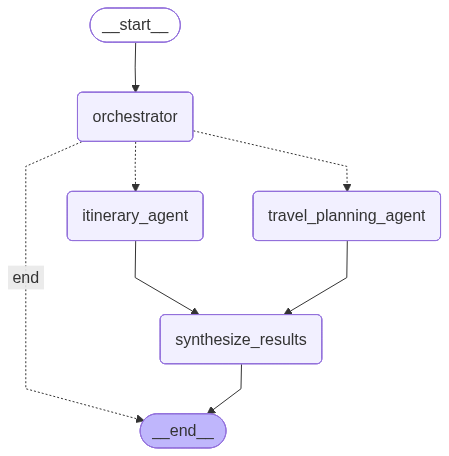

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 7: Persistance

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = build.compile(checkpointer=memory)

In [ ]:
def new_thread():
    """Creates a new session/thread id for memory management."""
    return {
        "configurable": {
            "thread_id": str(uuid())
        }
    }

## Test

In [ ]:
config = new_thread()

result = graph.invoke(
    {
        "user_input": "Plan a trip from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult. Also, provide an itinerary for the trip.",
        "selected_workers": [],
        "worker_outputs": [],
        "messages": [],
        "final_output": ""
    },
    config=config
)

print(result["final_output"])

Tool calls: [{'name': 'route_selection', 'args': {'query': 'trip planning from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult'}, 'id': 'call_s4QD4hWrvktgGJ3UdETkHghI', 'type': 'tool_call'}, {'name': 'route_selection', 'args': {'query': 'itinerary generation for trip from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult'}, 'id': 'call_vtVJMnA61J3D32iDWft4Zw37', 'type': 'tool_call'}]
Decision Trace: 
Selected Route: ['travel_planning_agent', 'itinerary_agent']
{'departure_location': 'Delhi', 'arrival_location': 'Mumbai'}
['DEL', 'BOM']
### Trip Plan from Delhi to Mumbai

**Travel Dates:**
- Departure: 17th June 2026
- Return: 23rd June 2026
- Number of Adults: 1

**Flight Options:**
Here are the best flight options available for your trip:

1. **IndiGo (Flight Number: 6E 322)**
   - **Departure:** 17th June 2026, 23:30 from Indira Gandhi International Airport (DEL)
   - **Arrival:** 18th June 2026, 01:45 at Chhatrapati Shivaji Maharaj

In [ ]:
result = graph.invoke(
    {
        "user_input": "Summarise the plan",
        "selected_workers": [],
        "worker_outputs": [],
        "messages": [],
        "final_output": ""
    },
    config=config
)

print(result["final_output"])

Tool calls: []
### Trip Summary from Delhi to Mumbai

**Travel Dates:**
- **Departure:** 17th June 2026
- **Return:** 23rd June 2026
- **Number of Adults:** 1

**Flight Details:**
- **Airline:** IndiGo
- **Flight Number:** 6E 322
- **Departure:** 17th June 2026, 23:30 from Delhi (DEL)
- **Arrival:** 18th June 2026, 01:45 in Mumbai (BOM)
- **Price:** ₹14,644

### Itinerary Overview
1. **Day 1 (18th June):** Arrival in Mumbai, explore local area and visit Gateway of India.
2. **Day 2 (19th June):** City tour including Chhatrapati Shivaji Maharaj Terminus and Marine Drive.
3. **Day 3 (20th June):** Cultural experience with a guided tour of Dharavi Slum.
4. **Day 4 (21st June):** Leisure day at Juhu Beach or local spa.
5. **Day 5 (22nd June):** Last-minute shopping and sightseeing.
6. **Day 6 (23rd June):** Return flight to Delhi.

Enjoy your trip!


In [ ]:
print("History length:", len(state.values.get("messages", [])))

History length: 2


In [ ]:
state = graph.get_state(config)

print("STATE KEYS:", state.values.keys())
print("MESSAGES:", state.values.get("messages"))

STATE KEYS: dict_keys(['user_input', 'selected_workers', 'worker_outputs', 'messages', 'final_output'])
MESSAGES: [HumanMessage(content='Plan a trip from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult. Also, provide an itinerary for the trip.', additional_kwargs={}, response_metadata={}, id='1a785637-dbfe-4261-a0bd-8187a4ee77a8'), AIMessage(content='### Trip Plan from Delhi to Mumbai\n\n**Travel Dates:**\n- Departure: 17th June 2026\n- Return: 23rd June 2026\n- Number of Adults: 1\n\n**Flight Options:**\nHere are the best flight options available for your trip:\n\n1. **IndiGo (Flight Number: 6E 322)**\n   - **Departure:** 17th June 2026, 23:30 from Indira Gandhi International Airport (DEL)\n   - **Arrival:** 18th June 2026, 01:45 at Chhatrapati Shivaji Maharaj International Airport (BOM)\n   - **Duration:** 2 hours 15 minutes\n   - **Price:** ₹14,644\n   - **Legroom:** 28 inches\n   - **Carbon Emissions:** 85 kg\n\n2. **Air India (Flight Number: IX 1235)**\n